## CNNs

In [1]:
import torch
import torchvision

In [2]:
from torchvision import datasets
from torchvision.transforms import ToTensor

train_data=datasets.FashionMNIST(
                            root="data",
                            train= True,
                            download= False,
                            transform=ToTensor()
                            )
test_data=datasets.FashionMNIST(
                            root="data",
                            train= False,
                            download= False,
                            transform=ToTensor()
                            )

In [3]:
img, label =train_data[0]
img, label

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.0039, 

In [4]:
img.shape

torch.Size([1, 28, 28])

In [5]:
len(train_data), len(test_data)

(60000, 10000)

In [6]:
classes=train_data.classes
classes

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [7]:
class_to_idx=train_data.class_to_idx
class_to_idx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

In [8]:
from torch.utils.data import DataLoader
batch_size=32
train_dataloader=DataLoader(
                            dataset=train_data,
                            batch_size=batch_size,
                            shuffle=True
                            )

test_dataloader=DataLoader(
                            dataset=test_data,
                            batch_size=batch_size,
                            shuffle=False
                            )
print(f"Dataloader:{train_dataloader, test_dataloader}")
print(f"Length of train dataloader: {len(train_dataloader)} batches of {batch_size}")
print(f"Length of test dataloader: {len(test_dataloader)} batches of {batch_size}")

Dataloader:(<torch.utils.data.dataloader.DataLoader object at 0x78031c3a33e0>, <torch.utils.data.dataloader.DataLoader object at 0x78031cb7b260>)
Length of train dataloader: 1875 batches of 32
Length of test dataloader: 313 batches of 32


In [9]:
len(train_dataloader), len(test_dataloader)

(1875, 313)

which means 1875*32=60000

In [10]:
from torch import nn

class cnn(nn.Module):
    """This is a TinyVGG Arch"""
    def __init__(self,input:int,hidden:int,output:int):
        super().__init__()
        self.conv_block1=nn.Sequential(
            nn.Conv2d(in_channels=input,
                    out_channels=hidden,
                    kernel_size=3,
                    stride=1,
                    padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden,
                    out_channels=hidden,
                    kernel_size=3,
                    stride=1,
                    padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.conv_block2=nn.Sequential(
            nn.Conv2d(in_channels=hidden,
                    out_channels=hidden,
                    kernel_size=3,
                    stride=1,
                    padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden,
                    out_channels=hidden,
                    kernel_size=3,
                    stride=1,
                    padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.classifier=nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden*7*7,
                      out_features=output)
        )

    def forward(self, x):
        x= self.conv_block1(x)
        #print(x.shape)
        x= self.conv_block2(x)
        #print(x.shape)
        x= self.classifier(x)
        return x


In [11]:
model2=cnn(input=1, hidden=10, output=len(classes))
model2

cnn(
  (conv_block1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

### How can we know what to pass to Linear layer after Flatten?

1. Do a dummy pass as below, it will show what Linear layer is expecting as input size

2. Use below formulas to calculate

Conv2d:    O = ⌊(W + 2P − K)/S⌋ + 1,   C_out = as chosen

MaxPool:   O = ⌊(W + 2P − K)/S⌋ + 1,   C unchanged (defaults: S=K, P=0)

Same size: P = (K−1)/2 and S = 1

Flatten:   features = C·H·W

Linear:    in_features must equal flattened size

Batch dim: never changes through any of these layers

dummy = torch.randn(1, 1, 28, 28)

out = model2.conv_block2(model2.conv_block1(dummy))

print(out.shape)  # torch.Size([1, 10, 7, 7]) → in_features = 10*7*7

In [12]:
model2.state_dict()

OrderedDict([('conv_block1.0.weight',
              tensor([[[[-1.9991e-02,  5.2205e-02,  3.2772e-01],
                        [-3.5852e-02,  1.4535e-01,  1.0130e-02],
                        [-2.9943e-02,  1.4937e-01, -1.9104e-01]]],
              
              
                      [[[-2.1627e-01, -1.1735e-01, -2.7983e-01],
                        [ 8.5799e-02, -2.1266e-01,  3.2352e-01],
                        [ 1.5076e-02,  1.8561e-01, -1.9131e-01]]],
              
              
                      [[[-2.5553e-01, -1.9327e-01,  1.2198e-01],
                        [ 3.0502e-01, -1.5097e-01, -1.6986e-02],
                        [-2.5777e-01, -2.1438e-01,  1.8410e-01]]],
              
              
                      [[[-1.8779e-01, -9.1568e-02, -2.4873e-01],
                        [-2.7479e-01,  2.5978e-03, -1.7360e-02],
                        [-2.6619e-02,  2.5315e-01,  2.2872e-01]]],
              
              
                      [[[-3.1474e-01,  1.8539e-01,  2.

### with sample data below to see how conv is working

In [13]:
torch.manual_seed(42)

images= torch.randn(size=(32,3,64,64))
test_image=images[0]
print(f"Image batch shape: {images.shape} -> [batch_size, color_channels, height, width]")
print(f"Single image shape: {test_image.shape} -> [color_channels, height, width]") 
print(f"Single image pixel values:\n{test_image}")

Image batch shape: torch.Size([32, 3, 64, 64]) -> [batch_size, color_channels, height, width]
Single image shape: torch.Size([3, 64, 64]) -> [color_channels, height, width]
Single image pixel values:
tensor([[[ 1.9269,  1.4873,  0.9007,  ...,  1.8446, -1.1845,  1.3835],
         [ 1.4451,  0.8564,  2.2181,  ...,  0.3399,  0.7200,  0.4114],
         [ 1.9312,  1.0119, -1.4364,  ..., -0.5558,  0.7043,  0.7099],
         ...,
         [-0.5610, -0.4830,  0.4770,  ..., -0.2713, -0.9537, -0.6737],
         [ 0.3076, -0.1277,  0.0366,  ..., -2.0060,  0.2824, -0.8111],
         [-1.5486,  0.0485, -0.7712,  ..., -0.1403,  0.9416, -0.0118]],

        [[-0.5197,  1.8524,  1.8365,  ...,  0.8935, -1.5114, -0.8515],
         [ 2.0818,  1.0677, -1.4277,  ...,  1.6612, -2.6223, -0.4319],
         [-0.1010, -0.4388, -1.9775,  ...,  0.2106,  0.2536, -0.7318],
         ...,
         [ 0.2779,  0.7342, -0.3736,  ..., -0.4601,  0.1815,  0.1850],
         [ 0.7205, -0.2833,  0.0937,  ..., -0.1002, -2.3609,

In [14]:
test_image.shape

torch.Size([3, 64, 64])

In [15]:
torch.manual_seed(42)

# Create a convolutional layer with same dimensions as TinyVGG 
# (try changing any of the parameters and see what happens)
conv_layer = nn.Conv2d(in_channels=3,
                       out_channels=10,
                       kernel_size=3,
                       stride=1,
                       padding=0) # also try using "valid" or "same" here 

# Pass the data through the convolutional layer
conv_output=conv_layer(test_image) # Note: If running PyTorch <1.11.0, this will error because of shape issues (nn.Conv.2d() expects a 4d tensor as input) 

In [16]:
conv_output.shape

torch.Size([10, 62, 62])

In [17]:
# Add extra dimension to test image
test_image.unsqueeze(dim=0).shape

torch.Size([1, 3, 64, 64])

In [18]:
# Pass test image with extra dimension through conv_layer
conv_layer(test_image.unsqueeze(dim=0)).shape

torch.Size([1, 10, 62, 62])

In [19]:
torch.manual_seed(42)
# Create a new conv_layer with different values (try setting these to whatever you like)
conv_layer_2 = nn.Conv2d(in_channels=3, # same number of color channels as our input image
                         out_channels=10,
                         kernel_size=(5, 5), # kernel is usually a square so a tuple also works
                         stride=2,
                         padding=0)

# Pass single image through new conv_layer_2 (this calls nn.Conv2d()'s forward() method on the input)
conv_layer_2(test_image.unsqueeze(dim=0)).shape

torch.Size([1, 10, 30, 30])

In [20]:
# Check out the conv_layer_2 internal parameters
print(conv_layer_2.state_dict())

OrderedDict({'weight': tensor([[[[ 0.0883,  0.0958, -0.0271,  0.1061, -0.0253],
          [ 0.0233, -0.0562,  0.0678,  0.1018, -0.0847],
          [ 0.1004,  0.0216,  0.0853,  0.0156,  0.0557],
          [-0.0163,  0.0890,  0.0171, -0.0539,  0.0294],
          [-0.0532, -0.0135, -0.0469,  0.0766, -0.0911]],

         [[-0.0532, -0.0326, -0.0694,  0.0109, -0.1140],
          [ 0.1043, -0.0981,  0.0891,  0.0192, -0.0375],
          [ 0.0714,  0.0180,  0.0933,  0.0126, -0.0364],
          [ 0.0310, -0.0313,  0.0486,  0.1031,  0.0667],
          [-0.0505,  0.0667,  0.0207,  0.0586, -0.0704]],

         [[-0.1143, -0.0446, -0.0886,  0.0947,  0.0333],
          [ 0.0478,  0.0365, -0.0020,  0.0904, -0.0820],
          [ 0.0073, -0.0788,  0.0356, -0.0398,  0.0354],
          [-0.0241,  0.0958, -0.0684, -0.0689, -0.0689],
          [ 0.1039,  0.0385,  0.1111, -0.0953, -0.1145]]],


        [[[-0.0903, -0.0777,  0.0468,  0.0413,  0.0959],
          [-0.0596, -0.0787,  0.0613, -0.0467,  0.0701],


In [21]:
# Get shapes of weight and bias tensors within conv_layer_2
print(f"conv_layer_2 weight shape: \n{conv_layer_2.weight.shape} -> [out_channels=10, in_channels=3, kernel_size=5, kernel_size=5]")
print(f"\nconv_layer_2 bias shape: \n{conv_layer_2.bias.shape} -> [out_channels=10]")

conv_layer_2 weight shape: 
torch.Size([10, 3, 5, 5]) -> [out_channels=10, in_channels=3, kernel_size=5, kernel_size=5]

conv_layer_2 bias shape: 
torch.Size([10]) -> [out_channels=10]


### See maxpool layer

In [22]:
# Print out original image shape without and with unsqueezed dimension
print(f"Test image original shape: {test_image.shape}")
print(f"Test image with unsqueezed dimension: {test_image.unsqueeze(dim=0).shape}")

# Create a sample nn.MaxPoo2d() layer
max_pool_layer = nn.MaxPool2d(kernel_size=2)

# Pass data through just the conv_layer
test_image_through_conv = conv_layer(test_image.unsqueeze(dim=0))
print(f"Shape after going through conv_layer(): {test_image_through_conv.shape}")

# Pass data through the max pool layer
test_image_through_conv_and_max_pool = max_pool_layer(test_image_through_conv)
print(f"Shape after going through conv_layer() and max_pool_layer(): {test_image_through_conv_and_max_pool.shape}")

Test image original shape: torch.Size([3, 64, 64])
Test image with unsqueezed dimension: torch.Size([1, 3, 64, 64])
Shape after going through conv_layer(): torch.Size([1, 10, 62, 62])
Shape after going through conv_layer() and max_pool_layer(): torch.Size([1, 10, 31, 31])


In [23]:
torch.manual_seed(42)
# Create a random tensor with a similar number of dimensions to our images
random_tensor = torch.randn(size=(1, 1, 2, 2))
print(f"Random tensor:\n{random_tensor}")
print(f"Random tensor shape: {random_tensor.shape}")

# Create a max pool layer
max_pool_layer = nn.MaxPool2d(kernel_size=2) # see what happens when you change the kernel_size value 

# Pass the random tensor through the max pool layer
max_pool_tensor = max_pool_layer(random_tensor)
print(f"\nMax pool tensor:\n{max_pool_tensor} <- this is the maximum value from random_tensor")
print(f"Max pool tensor shape: {max_pool_tensor.shape}")

Random tensor:
tensor([[[[0.3367, 0.1288],
          [0.2345, 0.2303]]]])
Random tensor shape: torch.Size([1, 1, 2, 2])

Max pool tensor:
tensor([[[[0.3367]]]]) <- this is the maximum value from random_tensor
Max pool tensor shape: torch.Size([1, 1, 1, 1])


In [24]:
loss_fn=nn.CrossEntropyLoss()
optimizer=torch.optim.AdamW(params=model2.parameters(), lr=0.001)

In [25]:
device="cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [26]:
model2.to(device)

cnn(
  (conv_block1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

In [27]:
from torchmetrics import Accuracy

metric=Accuracy(task="multiclass", num_classes=len(classes))

metric.to(device)
metric.device

device(type='cuda', index=0)

In [28]:
from torch.utils.tensorboard import SummaryWriter
# Create a writer with all default settings
writer = SummaryWriter()

In [29]:
torch.manual_seed(42)

epochs=3
train_loss=0
for epoch in range(epochs):
    print(f"Epochs: {epoch}")
    model2.train()
    for batch,(x,y) in enumerate(train_dataloader):
        x=x.to(device)
        y=y.to(device)
        y_preds=model2(x)
        loss=loss_fn(y_preds,y)
        train_loss+=loss
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if batch % 400 ==0:
            print(f"number of samples seen: {batch * len(x)}/{len(train_dataloader.dataset)}")
    train_loss /=len(train_dataloader)

    test_loss,test_acc=0,0
    model2.eval()
    with torch.inference_mode():
        for x,y in test_dataloader :
            x=x.to(device)
            y=y.to(device)
            y_preds_test=model2(x)
            loss1=loss_fn(y_preds_test,y)
            test_loss+=loss1
            acc=metric(y_preds_test,y)
            test_acc+=acc

        test_loss /=len(test_dataloader)
        test_acc/=len(test_dataloader)
    print(f"\nTrain loss: {train_loss:.5f} | Test loss: {test_loss:.5f}, Test acc: {test_acc*100:.2f}%\n")



Epochs: 0
number of samples seen: 0/60000
number of samples seen: 12800/60000
number of samples seen: 25600/60000
number of samples seen: 38400/60000
number of samples seen: 51200/60000

Train loss: 0.55433 | Test loss: 0.41005, Test acc: 85.34%

Epochs: 1
number of samples seen: 0/60000
number of samples seen: 12800/60000
number of samples seen: 25600/60000
number of samples seen: 38400/60000
number of samples seen: 51200/60000

Train loss: 0.35810 | Test loss: 0.36289, Test acc: 86.86%

Epochs: 2
number of samples seen: 0/60000
number of samples seen: 12800/60000
number of samples seen: 25600/60000
number of samples seen: 38400/60000
number of samples seen: 51200/60000

Train loss: 0.31639 | Test loss: 0.34176, Test acc: 87.39%



In [30]:
### New: Experiment tracking ###
        # Add loss results to SummaryWriter
writer.add_scalars(main_tag="Loss", 
                           tag_scalar_dict={"train_loss": train_loss,
                                            "test_loss": test_loss},
                           global_step=epoch)

        # Add accuracy results to SummaryWriter
writer.add_scalars(main_tag="Accuracy", 
                           tag_scalar_dict={"test_acc": test_acc}, 
                           global_step=epoch)
        
        # Track the PyTorch model architecture
writer.add_graph(model=model2, 
                         # Pass in an example input
                input_to_model=torch.randn(32, 1, 28, 28).to(device))
    
    # Close the writer
writer.close()
    

In [31]:
torch.save(model2.state_dict(), "data/cnn.pt")

#### SAVE: Only the learned weights (recommended)

torch.save(model.state_dict(), "my_model.pt")

#### SAVE: Full checkpoint (for resuming training)

torch.save({
    "epoch": epoch,
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "train_loss": train_loss,
}, "checkpoint.pt")


Lets evaluate using confusuion matrix

In [32]:
# Import tqdm for progress bar
from tqdm.auto import tqdm

# 1. Make predictions with trained model
y_preds = []
model2.eval()
with torch.inference_mode():
  for X, y in tqdm(test_dataloader, desc="Making predictions"):
    # Send data and targets to target device
    X, y = X.to(device), y.to(device)
    # Do the forward pass
    y_logit = model2(X)
    # Turn predictions from logits -> prediction probabilities -> predictions labels
    y_pred = torch.softmax(y_logit, dim=1).argmax(dim=1) # note: perform softmax on the "logits" dimension, not "batch" dimension (in this case we have a batch size of 32, so can perform on dim=1)
    # Put predictions on CPU for evaluation
    y_preds.append(y_pred.cpu())
# Concatenate list of predictions into a tensor
y_pred_tensor = torch.cat(y_preds)

/home/reddy/pytorch/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Making predictions: 100%|██████████| 313/313 [00:00<00:00, 1094.82it/s]


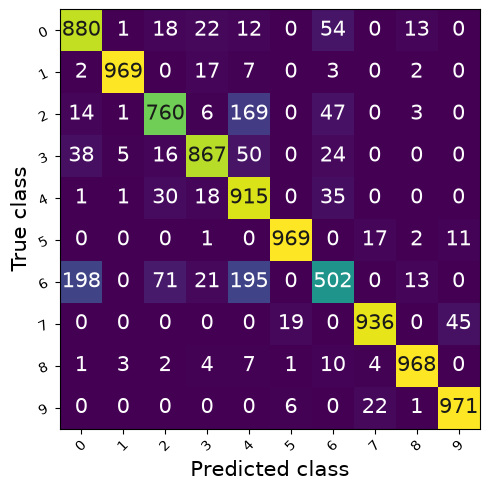

In [33]:
from torchmetrics import ConfusionMatrix
import matplotlib.pyplot as plt

# 2. Setup confusion matrix instance and compare predictions to targets
confmat = ConfusionMatrix(num_classes=len(classes), task='multiclass')
confmat_tensor = confmat(preds=y_pred_tensor,
                         target=test_data.targets)

fig = confmat.plot()

# 4. Display or save
plt.show()

#### How to Load & Reuse the Model

You must define the model architecture first, then load the weights into it:

In [34]:
import torch
import torch.nn as nn

# 1. Define the exact same architecture (must match saved model)
class MyModel(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        # ... your layers ...

    def forward(self, x):
        # ... your forward pass ...

# 2. Instantiate the model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MyModel(num_classes=10).to(device)

# 3. Load the saved weights
model.load_state_dict(torch.load("my_model.pt", map_location=device, weights_only=True))

# 4. Set to evaluation mode (crucial for dropout/batchnorm)
model.eval()

# 🔁 REUSE: Make predictions
with torch.no_grad():  # Speeds up inference & disables gradient tracking
    x_test = test_data[0][0].unsqueeze(0).to(device)  # Add batch dim
    output = model(x_test)
    preds = output.argmax(dim=1)
    print(f"Predicted class: {preds.item()}")


IndentationError: expected an indented block after function definition on line 10 (644126036.py, line 14)

In [ ]:
# load_model.py
def load_model(path, device):
    model = MyModel(num_classes=10).to(device)
    model.load_state_dict(torch.load(path, map_location=device, weights_only=True))
    model.eval()
    return model

# inference.py
model = load_model("my_model.pt", device)

with torch.no_grad():
    # Preprocess & batch your input
    x = preprocess_batch(inputs).to(device)
    logits = model(x)
    probabilities = torch.softmax(logits, dim=1)
    predictions = probabilities.argmax(dim=1)
